In [2]:
import torch
import time

def check_cuda_cudnn():
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("PyTorch CUDA build:", torch.version.cuda)
    print("cuDNN enabled:", torch.backends.cudnn.enabled)
    print("cuDNN version:", torch.backends.cudnn.version())

    if torch.cuda.is_available():
        print("GPU count:", torch.cuda.device_count())
        print("GPU name:", torch.cuda.get_device_name(0))
        print("Current device:", torch.cuda.current_device())

        x = torch.randn(2048, 2048, device="cuda")
        y = torch.randn(2048, 2048, device="cuda")

        torch.cuda.synchronize()
        start = time.time()
        _ = x @ y
        torch.cuda.synchronize()
        print("GPU matmul test OK. Time:", round(time.time() - start, 4), "sec")
    else:
        print("CUDA not available. Training will run on CPU.")

check_cuda_cudnn()


PyTorch: 2.5.1+cu121
CUDA available: True
PyTorch CUDA build: 12.1
cuDNN enabled: True
cuDNN version: 90100
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU
Current device: 0
GPU matmul test OK. Time: 0.2023 sec


In [3]:
def check_loader(loader, name="train_loader", max_batches=5):
    print(f"Checking {name}...")

    start = time.time()
    for i, batch in enumerate(loader):
        print(f"Batch {i} loaded")

        if isinstance(batch, (list, tuple)):
            for j, item in enumerate(batch):
                if torch.is_tensor(item):
                    print(f"  item {j}: shape={tuple(item.shape)}, device={item.device}, dtype={item.dtype}")
        elif isinstance(batch, dict):
            for k, v in batch.items():
                if torch.is_tensor(v):
                    print(f"  {k}: shape={tuple(v.shape)}, device={v.device}, dtype={v.dtype}")

        if i + 1 >= max_batches:
            break

    print("Loader check time:", round(time.time() - start, 2), "sec")


def debug_one_training_step(trainer, train_loader, class_weights, phase="phase1", dry_run=True):
    config = trainer.config
    model = trainer.model

    print("Device:", config.DEVICE)
    print("CUDA available:", torch.cuda.is_available())
    print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
    print("cuDNN:", torch.backends.cudnn.version(), torch.backends.cudnn.enabled)

    start = time.time()
    batch = next(iter(train_loader))
    print("Batch load time:", round(time.time() - start, 3), "sec")

    for k, v in batch.items():
        if torch.is_tensor(v):
            print(k, tuple(v.shape), v.dtype, v.device)

    optimizer = trainer._get_optimizer(phase)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(config.DEVICE))

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable {phase} params:", trainable)

    start = time.time()
    images = batch["image"].to(config.DEVICE, non_blocking=True)
    masks = batch["mask"].to(config.DEVICE, non_blocking=True)
    morphology = batch["morphology"].to(config.DEVICE, non_blocking=True)
    metadata = batch["metadata"].to(config.DEVICE, non_blocking=True)
    labels = batch["label"].to(config.DEVICE, non_blocking=True)

    if config.DEVICE.type == "cuda":
        torch.cuda.synchronize()

    print("Copy to device:", round(time.time() - start, 3), "sec")

    model.train()
    optimizer.zero_grad(set_to_none=True)

    start = time.time()
    logits, _ = model(images, masks, morphology, metadata)
    loss = criterion(logits, labels)

    if config.DEVICE.type == "cuda":
        torch.cuda.synchronize()

    print("Forward:", round(time.time() - start, 3), "sec")
    print("Loss:", loss.item())

    start = time.time()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    if dry_run:
        optimizer.zero_grad(set_to_none=True)
        print("Dry run: optimizer step skipped")
    else:
        optimizer.step()

    if config.DEVICE.type == "cuda":
        torch.cuda.synchronize()
        print("CUDA max memory GB:", round(torch.cuda.max_memory_allocated() / 1024**3, 3))

    print("Backward" + (" only" if dry_run else " + step") + ":", round(time.time() - start, 3), "sec")


In [4]:
# ==============================================================================
# 0. ENVIRONMENT CHECK
# ==============================================================================
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4060 Laptop GPU
Using device    : cuda


In [5]:
# ==============================================================================
# 1. IMPORTS
# ==============================================================================
import os
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

try:
    from tqdm.auto import tqdm
except ImportError:
    class _NoOpTqdm:
        def __init__(self, iterable, **kwargs):
            self.iterable = iterable
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix(self, *args, **kwargs):
            pass
    def tqdm(iterable, **kwargs):
        return _NoOpTqdm(iterable, **kwargs)

C:\Users\Jaswant singh\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# ==============================================================================
# 2. CONFIGURATION
# ==============================================================================
class Config:
    """Central configuration — update DATA_DIR to your actual path."""
    DATA_DIR       = r'D:\amlan project\HAM10000'
    IMAGE_DIR      = os.path.join(DATA_DIR, 'images/')
    MASK_DIR       = os.path.join(DATA_DIR, 'masks/')
    METADATA_CSV   = os.path.join(DATA_DIR, 'HAM10000_metadata.csv')
    ENCODER_CKPT   = r'D:\amlan project\swinunet\swinunet_v4_encoder.pth'
    CHECKPOINT_DIR = r'D:\amlan project\Kimi phase 4\output\checkpoints_phase4'

    # Backward-compatible aliases
    ENCODER_CHECKPOINT = ENCODER_CKPT
    SAVE_DIR = CHECKPOINT_DIR

    # Training
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    NUM_CLASSES = 7

    # Phase 1 (frozen encoder)
    PHASE1_EPOCHS = 10
    PHASE1_LR = 1e-3

    # Phase 2 (unfrozen encoder)
    PHASE2_EPOCHS = 50
    ENCODER_LR = 1e-5
    HEAD_LR = 5e-5

    # Early stopping
    EARLY_STOPPING_PATIENCE = 10

    # Morphology / Metadata
    MORPH_DIM = 32
    META_DIM = 32

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# ==============================================================================
# 3. REPRODUCIBILITY
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [8]:
# ==============================================================================
# 4. MORPHOLOGY EXTRACTION (OpenCV — compatible with CV3 & CV4)
# ==============================================================================
def extract_morphology(mask_np):
    """Extract 5 ABCD morphology features from a binary/near-binary mask."""
    mask_bin = (mask_np > 0.5).astype(np.uint8)

    # OpenCV 3.x returns (img, contours, hierarchy); 4.x returns (contours, hierarchy)
    result = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = result[0] if len(result) == 2 else result[1]

    if not contours:
        return np.zeros(5, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if area < 10 or perimeter < 1:
        return np.zeros(5, dtype=np.float32)

    # Asymmetry
    asymmetry = 0.0
    if len(cnt) >= 5:
        try:
            _, axes, _ = cv2.fitEllipse(cnt)
            major = max(axes)
            minor = min(axes)
            if major > 0:
                asymmetry = 1.0 - (minor / major)
        except Exception:
            asymmetry = 0.0

    # Border irregularity & compactness
    compactness = (4.0 * np.pi * area) / (perimeter ** 2 + 1e-8)
    border_irregularity = 1.0 - compactness

    # Color variance placeholder
    color_variance = 0.0

    # Diameter (normalized by 224)
    diameter = np.sqrt(4.0 * area / np.pi) / 224.0

    return np.array([asymmetry, border_irregularity, color_variance,
                     compactness, diameter], dtype=np.float32)


def extract_morphology_with_color(mask_np, image_np):
    """Extract morphology + color variance from masked uint8 RGB image."""
    features = extract_morphology(mask_np)
    mask_bin = (mask_np > 0.5).astype(np.uint8)
    if mask_bin.sum() > 0:
        masked_pixels = image_np[mask_bin > 0]
        if len(masked_pixels) > 0:
            color_std = np.std(masked_pixels, axis=0).mean()
            features[2] = color_std / 50.0
    return features

In [9]:
# ==============================================================================
# 5. DATASET (Image + Mask + Morphology + Metadata)
# ==============================================================================
class HAM10000Dataset_Morphology(Dataset):
    """
    Returns dict with keys:
        'image', 'mask', 'morphology', 'metadata', 'label'
    """

    def __init__(self, df, img_dir, mask_dir, transform=None, mode='train',
                 img_size=224, sex_map=None, site_to_idx=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mode = mode
        self.img_size = img_size
        self.sex_map = sex_map or {'male': 0.0, 'female': 1.0, 'unknown': 2.0}
        self.site_to_idx = site_to_idx or {}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']
        label = int(row['label'])

        # Load image
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = np.array(Image.open(img_path).convert("RGB"))

        # Load mask (HAM10000 masks are .png)
        mask_path = os.path.join(self.mask_dir, f"{img_id}_segmentation.png")
        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.mask_dir, f"{img_id}.png")
        mask = np.array(Image.open(mask_path).convert("L")) / 255.0

        # Resize for consistent morphology extraction
        image_resized = cv2.resize(image, (self.img_size, self.img_size))
        mask_resized = cv2.resize(mask.astype(np.float32), (self.img_size, self.img_size))

        # Extract morphology BEFORE albumentations (still in uint8 RGB space)
        morphology = extract_morphology_with_color(mask_resized, image_resized)
        morphology = torch.tensor(morphology, dtype=torch.float32)

        # Encode metadata
        age = row['age'] if not pd.isna(row['age']) else 50.0
        age_norm = age / 100.0
        sex_val = self.sex_map.get(row['sex'], 2.0)
        site_val = self.site_to_idx.get(row['localization'], 0)
        metadata = torch.tensor([age_norm, sex_val, float(site_val)], dtype=torch.float32)

        # Albumentations transforms
        if self.transform:
            augmented = self.transform(image=image_resized, mask=mask_resized)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = torch.from_numpy(image_resized.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask_resized).float()

        # Ensure mask is a torch tensor with shape (1, H, W)
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).float()
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        elif mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask.permute(2, 0, 1)
        elif mask.ndim == 3 and mask.shape[0] != 1:
            mask = mask.unsqueeze(0)

        return {
            'image': image,
            'mask': mask,
            'morphology': morphology,
            'metadata': metadata,
            'label': torch.tensor(label, dtype=torch.long)
        }

In [10]:
# ==============================================================================
# 6. ALBUMENTATIONS TRANSFORMS (API >= 1.4 compatible)
# ==============================================================================
def get_transforms(img_size=224, mode='train'):
    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Rotate(limit=30, p=0.5),
            A.ElasticTransform(alpha=1, sigma=50, p=0.3),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
            A.GaussianBlur(blur_limit=3, p=0.3),
            A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(1, 32),
                            hole_width_range=(1, 32), p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

In [11]:
# ==============================================================================
# 7. FPN
# ==============================================================================
class FeaturePyramidNetwork(nn.Module):
    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for in_ch in in_channels_list
        ])
        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for _ in in_channels_list
        ])

    def forward(self, features):
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(laterals[i], size=laterals[i-1].shape[2:], mode='nearest')
            laterals[i-1] = laterals[i-1] + upsampled
        return [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]

In [12]:
# ==============================================================================
# 8. MORPHOLOGY ENCODER
# ==============================================================================
class MorphologyEncoder(nn.Module):
    def __init__(self, in_dim=5, out_dim=32):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 16),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(16, out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, morphology):
        return self.mlp(morphology)

In [13]:
# ==============================================================================
# 9. METADATA ENCODER (Tabular: age + sex + site)
# ==============================================================================
class MetadataEncoder(nn.Module):
    """
    Encodes categorical site via Embedding and fuses with continuous age/sex.
    """
    def __init__(self, num_sites, embed_dim=16, out_dim=32):
        super().__init__()
        self.site_embed = nn.Embedding(num_sites, embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(1 + 1 + embed_dim, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(32, out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, metadata):
        # metadata: (B, 3) -> [age_norm, sex_code, site_code]
        age = metadata[:, 0:1]
        sex = metadata[:, 1:2]
        site = metadata[:, 2].long()
        site_vec = self.site_embed(site)
        x = torch.cat([age, sex, site_vec], dim=1)
        return self.mlp(x)

In [15]:
# ==============================================================================
# 10. SPATIAL CROSS-ATTENTION FUSION (Core of V7)
# ==============================================================================
class SpatialCrossAttentionFusion(nn.Module):
    """
    Morphology acts as QUERY attending to Image spatial tokens (KEY/VALUE).
    Input:
        img_tokens : (B, N, img_dim)   e.g., N=196, img_dim=256
        morph_feat : (B, morph_dim)     e.g., 32
    Output:
        fused      : (B, img_dim)       attended context
        attn_weights: (B, N)            explainability heatmap
    """

    def __init__(self, img_dim=256, morph_dim=32, num_heads=4, dropout=0.1):
        super().__init__()
        self.q_proj = nn.Linear(morph_dim, img_dim)
        self.kv_proj = nn.Linear(img_dim, img_dim)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=img_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.ffn = nn.Sequential(
            nn.Linear(img_dim, img_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(img_dim * 2, img_dim),
            nn.Dropout(dropout)
        )

        self.norm1 = nn.LayerNorm(img_dim)
        self.norm2 = nn.LayerNorm(img_dim)

    def forward(self, img_tokens, morph_feat):
        B, N, D = img_tokens.shape

        q = self.q_proj(morph_feat).unsqueeze(1)   # (B, 1, D)
        kv = self.kv_proj(img_tokens)              # (B, N, D)

        attn_out, attn_weights = self.cross_attn(q, kv, kv)
        # attn_out: (B, 1, D), attn_weights: (B, 1, N)

        out = self.norm1(q + attn_out)             # (B, 1, D)
        out = self.norm2(out + self.ffn(out))      # (B, 1, D)

        return out.squeeze(1), attn_weights.squeeze(1)  # (B,D), (B,N)

In [17]:
# ==============================================================================
# 11. V7 MODEL
# ==============================================================================
class SkinLesionClassifier_V7(nn.Module):
    """
    V7: Spatial Morphology-Gated Cross-Attention + Metadata Fusion.

    - Swin-B encoder (pretrained)
    - FPN (all scales -> 256 ch)
    - Masked token pooling on P4 (14x14)
    - Morphology Encoder (5-D -> 32-D)
    - Metadata Encoder (tabular -> 32-D)
    - Spatial Cross-Attention (morphology queries image tokens)
    - Classifier on [attended-visual | morph | meta]
    """

    def __init__(self, num_classes=7, pretrained=True,
                 encoder_checkpoint="swinunet_v4_encoder.pth",
                 num_sites=15, use_metadata=True):
        super().__init__()
        self.use_metadata = use_metadata

        # Encoder
        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )
        if pretrained and encoder_checkpoint and os.path.exists(encoder_checkpoint):
            ckpt = torch.load(encoder_checkpoint, map_location='cpu', weights_only=False)
            self.encoder.load_state_dict(ckpt, strict=False)
            print(f"Loaded encoder from {encoder_checkpoint}")

        # FPN
        self.fpn = FeaturePyramidNetwork([128, 256, 512, 1024], 256)

        # Modality encoders
        self.morphology_encoder = MorphologyEncoder(in_dim=5, out_dim=32)
        if use_metadata:
            self.metadata_encoder = MetadataEncoder(num_sites=num_sites, embed_dim=16, out_dim=32)
        else:
            self.metadata_encoder = None

        # Spatial cross-attention
        self.spatial_fusion = SpatialCrossAttentionFusion(
            img_dim=256, morph_dim=32, num_heads=4, dropout=0.1
        )

        # Classifier
        clf_in = 256 + 32 + (32 if use_metadata else 0)
        self.classifier = nn.Sequential(
            nn.Linear(clf_in, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def _to_channels_first(self, features):
        expected = [128, 256, 512, 1024]
        out = []
        for i, f in enumerate(features):
            if f.ndim == 4 and f.shape[-1] == expected[i]:
                f = f.permute(0, 3, 1, 2).contiguous()
            out.append(f)
        return out

    def _masked_pool_tokens(self, feat_map, mask):
        """
        feat_map: (B, C, H, W)
        mask:     (B, 1, H, W)
        Returns tokens (B, HW, C), mask_flat (B, HW)
        """
        B, C, H, W = feat_map.shape
        mask_r = F.interpolate(mask, size=(H, W), mode='nearest')
        tokens = feat_map.view(B, C, H * W).permute(0, 2, 1)   # (B, HW, C)
        mask_flat = mask_r.view(B, H * W)                      # (B, HW)

        # If mask is empty, attend to everything to avoid NaNs
        empty = (mask_flat.sum(dim=1, keepdim=True) < 1e-6).float()
        mask_flat = mask_flat + empty

        # Zero out background tokens
        tokens = tokens * mask_flat.unsqueeze(-1)
        return tokens, mask_flat

    def forward(self, image, mask, morphology, metadata=None):
        # Image encoding
        features = self._to_channels_first(self.encoder(image))

        # FPN
        fpn_features = self.fpn(features)

        # Use P4 (14x14) for spatial tokens
        p4 = fpn_features[2]  # (B, 256, 14, 14)

        # Masked pooling
        img_tokens, _ = self._masked_pool_tokens(p4, mask)  # (B, 196, 256)

        # Encode modalities
        morph_feat = self.morphology_encoder(morphology)  # (B, 32)
        meta_feat = None
        if self.use_metadata and metadata is not None:
            meta_feat = self.metadata_encoder(metadata)     # (B, 32)

        # Spatial cross-attention
        fused, attn_weights = self.spatial_fusion(img_tokens, morph_feat)
        # fused: (B, 256), attn_weights: (B, 196)

        # Concatenate all modalities
        concat = [fused, morph_feat]
        if meta_feat is not None:
            concat.append(meta_feat)
        fused_vec = torch.cat(concat, dim=1)

        # Classify
        logits = self.classifier(fused_vec)
        return logits, attn_weights

In [18]:
# ==============================================================================
# 12. CLASS WEIGHTS (computed on TRAIN split only)
# ==============================================================================
def get_class_weights(df):
    counts = df['label'].value_counts().sort_index().values
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * len(weights)
    return torch.tensor(weights, dtype=torch.float32)

In [19]:
# ==============================================================================
# 13. TRAINER
# ==============================================================================
class Trainer:
    def __init__(self, model, config, save_dir):
        self.model = model.to(config.DEVICE)
        self.config = config
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

        self.history = {
            'phase': [], 'epoch': [],
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'train_f1': [], 'val_f1': []
        }

    def _get_optimizer(self, phase='phase1'):
        if phase == 'phase1':
            for p in self.model.encoder.parameters():
                p.requires_grad = False

            params = [
                {'params': self.model.fpn.parameters()},
                {'params': self.model.morphology_encoder.parameters()},
                {'params': self.model.spatial_fusion.parameters()},
                {'params': self.model.classifier.parameters()}
            ]
            if self.model.metadata_encoder is not None:
                params.append({'params': self.model.metadata_encoder.parameters()})
            return torch.optim.AdamW(params, lr=self.config.PHASE1_LR, weight_decay=1e-4)

        if phase == 'phase2':
            for p in self.model.encoder.parameters():
                p.requires_grad = True

            params = [
                {'params': self.model.encoder.parameters(), 'lr': self.config.ENCODER_LR},
                {'params': self.model.fpn.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.morphology_encoder.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.spatial_fusion.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.classifier.parameters(), 'lr': self.config.HEAD_LR}
            ]
            if self.model.metadata_encoder is not None:
                params.append({'params': self.model.metadata_encoder.parameters(), 'lr': self.config.HEAD_LR})
            return torch.optim.AdamW(params, weight_decay=1e-4)

        raise ValueError("phase must be 'phase1' or 'phase2'")

    def _num_epochs(self, phase):
        return self.config.PHASE1_EPOCHS if phase == 'phase1' else self.config.PHASE2_EPOCHS

    def _phase_name(self, phase):
        return 'PHASE 1: Frozen encoder' if phase == 'phase1' else 'PHASE 2: Unfrozen encoder'

    def _checkpoint_path(self, phase):
        return os.path.join(self.save_dir, f'{phase}_latest.pth')

    def _best_model_path(self):
        return os.path.join(self.save_dir, 'best_model.pth')

    def _load_best_score(self):
        path = self._best_model_path()
        if not os.path.exists(path):
            return 0.0
        ckpt = torch.load(path, map_location=self.config.DEVICE, weights_only=False)
        return ckpt.get('best_val_f1', ckpt.get('val_f1', 0.0))

    def _save_checkpoint(self, phase, epoch, optimizer, scheduler, best_val_f1, patience_counter):
        ckpt = {
            'phase': phase,
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
            'history': self.history,
            'best_val_f1': best_val_f1,
            'patience_counter': patience_counter,
        }
        torch.save(ckpt, self._checkpoint_path(phase))

    def _resume_phase(self, phase, optimizer, scheduler, resume=True):
        best_val_f1 = self._load_best_score()
        patience_counter = 0
        start_epoch = 0

        if not resume:
            return start_epoch, best_val_f1, patience_counter

        ckpt_path = self._checkpoint_path(phase)
        if os.path.exists(ckpt_path):
            ckpt = torch.load(ckpt_path, map_location=self.config.DEVICE, weights_only=False)
            self.model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            if scheduler is not None and ckpt.get('scheduler_state_dict') is not None:
                scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            self.history = ckpt.get('history', self.history)
            best_val_f1 = ckpt.get('best_val_f1', best_val_f1)
            patience_counter = ckpt.get('patience_counter', 0)
            start_epoch = ckpt['epoch'] + 1
            print(f"Resuming {phase} from epoch {start_epoch + 1}")
            return start_epoch, best_val_f1, patience_counter

        # If starting phase2, seed from best model of phase1
        best_path = self._best_model_path()
        if phase == 'phase2' and os.path.exists(best_path):
            ckpt = torch.load(best_path, map_location=self.config.DEVICE, weights_only=False)
            self.model.load_state_dict(ckpt['model_state_dict'])
            self.history = ckpt.get('history', self.history)
            best_val_f1 = ckpt.get('best_val_f1', ckpt.get('val_f1', best_val_f1))
            print(f"Loaded best model before phase2 (val F1: {best_val_f1:.4f})")

        return start_epoch, best_val_f1, patience_counter

    def train_epoch(self, loader, criterion, optimizer, scheduler, epoch, total_epochs, phase):
        self.model.train()
        total_loss = 0
        all_preds, all_labels = [], []

        progress = tqdm(loader, desc=f"{phase} epoch {epoch + 1}/{total_epochs}", leave=True, mininterval=1.0)
        for batch_idx, batch in enumerate(progress):
            images = batch['image'].to(self.config.DEVICE, non_blocking=True)
            masks = batch['mask'].to(self.config.DEVICE, non_blocking=True)
            morphology = batch['morphology'].to(self.config.DEVICE, non_blocking=True)
            labels = batch['label'].to(self.config.DEVICE, non_blocking=True)
            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(self.config.DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits, _ = self.model(images, masks, morphology, metadata)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            progress.set_postfix(loss=f"{total_loss / (batch_idx + 1):.4f}")

        if scheduler is not None:
            scheduler.step()

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        return total_loss / len(loader), acc, f1

    @torch.no_grad()
    def evaluate(self, loader, criterion, desc='Validation'):
        self.model.eval()
        total_loss = 0
        all_preds, all_labels, all_probs, attn_stats = [], [], [], []

        for batch in tqdm(loader, desc=desc, leave=True, mininterval=1.0):
            images = batch['image'].to(self.config.DEVICE, non_blocking=True)
            masks = batch['mask'].to(self.config.DEVICE, non_blocking=True)
            morphology = batch['morphology'].to(self.config.DEVICE, non_blocking=True)
            labels = batch['label'].to(self.config.DEVICE, non_blocking=True)
            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(self.config.DEVICE, non_blocking=True)

            logits, attn_weights = self.model(images, masks, morphology, metadata)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            attn_stats.append(attn_weights.mean().item())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        try:
            auc = roc_auc_score(
                np.eye(self.config.NUM_CLASSES)[all_labels],
                np.array(all_probs),
                average='macro', multi_class='ovr'
            )
        except Exception:
            auc = 0.0

        return total_loss / len(loader), acc, f1, auc, np.mean(attn_stats)

    def fit_phase(self, phase, train_loader, val_loader, class_weights, resume=True):
        if phase not in {'phase1', 'phase2'}:
            raise ValueError("phase must be 'phase1' or 'phase2'")

        total_epochs = self._num_epochs(phase)
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(self.config.DEVICE))
        optimizer = self._get_optimizer(phase)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

        start_epoch, best_val_f1, patience_counter = self._resume_phase(phase, optimizer, scheduler, resume)

        print("\n" + "="*60)
        print(self._phase_name(phase))
        print("="*60)

        if start_epoch >= total_epochs:
            print(f"{phase} already complete.")
            print(f"Best validation F1: {best_val_f1:.4f}")
            return

        epoch_progress = tqdm(range(start_epoch, total_epochs), desc=f"{phase} epochs",
                              total=total_epochs, initial=start_epoch)
        for epoch in epoch_progress:
            train_loss, train_acc, train_f1 = self.train_epoch(
                train_loader, criterion, optimizer, scheduler, epoch, total_epochs, phase)
            val_loss, val_acc, val_f1, val_auc, avg_attn = self.evaluate(
                val_loader, criterion, desc=f"{phase} validation {epoch + 1}/{total_epochs}")

            epoch_progress.set_postfix({
                'train_loss': f"{train_loss:.4f}",
                'train_f1': f"{train_f1:.4f}",
                'val_loss': f"{val_loss:.4f}",
                'val_f1': f"{val_f1:.4f}",
                'best_f1': f"{max(best_val_f1, val_f1):.4f}"
            })

            print(f"Epoch {epoch+1}/{total_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} AUC: {val_auc:.4f} | "
                  f"Avg Attn: {avg_attn:.4f}")

            for k, v in zip(['phase', 'epoch', 'train_loss', 'val_loss',
                             'train_acc', 'val_acc', 'train_f1', 'val_f1'],
                            [phase, epoch + 1, train_loss, val_loss,
                             train_acc, val_acc, train_f1, val_f1]):
                self.history[k].append(v)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
                torch.save({
                    'phase': phase, 'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
                    'history': self.history,
                    'val_f1': val_f1, 'best_val_f1': best_val_f1,
                }, self._best_model_path())
                print(f"  -> Saved best model (val F1: {val_f1:.4f})")
            else:
                patience_counter += 1

            self._save_checkpoint(phase, epoch, optimizer, scheduler, best_val_f1, patience_counter)
            print(f"  -> Saved checkpoint: {self._checkpoint_path(phase)}")

            if phase == 'phase2' and patience_counter >= self.config.EARLY_STOPPING_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        print(f"\nBest validation F1: {best_val_f1:.4f}")

    def fit(self, train_loader, val_loader, class_weights, resume=True):
        self.fit_phase('phase1', train_loader, val_loader, class_weights, resume=resume)
        self.fit_phase('phase2', train_loader, val_loader, class_weights, resume=resume)

    def plot_history(self):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].plot(self.history['train_loss'], label='Train')
        axes[0].plot(self.history['val_loss'], label='Val')
        axes[0].set_title('Loss'); axes[0].legend()

        axes[1].plot(self.history['train_acc'], label='Train')
        axes[1].plot(self.history['val_acc'], label='Val')
        axes[1].set_title('Accuracy'); axes[1].legend()

        axes[2].plot(self.history['train_f1'], label='Train')
        axes[2].plot(self.history['val_f1'], label='Val')
        axes[2].set_title('Macro F1'); axes[2].legend()

        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, 'training_curves.png'))
        plt.show()

In [20]:
# ==============================================================================
# 14. EVALUATION
# ==============================================================================
def evaluate_model(model, test_loader, config, save_dir):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(config.DEVICE)
            masks = batch['mask'].to(config.DEVICE)
            morphology = batch['morphology'].to(config.DEVICE)
            labels = batch['label'].to(config.DEVICE)
            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(config.DEVICE)

            logits, _ = model(images, masks, morphology, metadata)
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    try:
        auc_macro = roc_auc_score(
            np.eye(config.NUM_CLASSES)[all_labels],
            np.array(all_probs),
            average='macro', multi_class='ovr'
        )
    except Exception:
        auc_macro = 0.0

    report = classification_report(
        all_labels, all_preds,
        target_names=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
        output_dict=True
    )

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
                yticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'])
    plt.title('Confusion Matrix - V7')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'))
    plt.show()

    print("\n" + "="*60)
    print("V7 TEST RESULTS - Spatial Morphology + Metadata Fusion")
    print("="*60)
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")
    print(f"Macro AUC: {auc_macro:.4f}")
    print("\nPer-class metrics:")
    for cls in ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']:
        print(f"  {cls:6s}: Precision={report[cls]['precision']:.4f}, "
              f"Recall={report[cls]['recall']:.4f}, F1={report[cls]['f1-score']:.4f}")

    print(f"\nTarget (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733")
    if f1_macro > 0.733:
        print("SUCCESS: Beat V4-C baseline!")
    else:
        print("NEEDS IMPROVEMENT")

    return {
        'accuracy': acc, 'macro_f1': f1_macro, 'weighted_f1': f1_weighted,
        'macro_auc': auc_macro, 'per_class': report, 'confusion_matrix': cm
    }

In [21]:
# ==============================================================================
# 15. ATTENTION VISUALIZATION (Explainability)
# ==============================================================================
def save_attention_visualizations(batch, model, config, save_dir, num_samples=4):
    """
    Save original image, mask, and morphology attention heatmap side-by-side.
    """
    model.eval()
    num_samples = min(num_samples, len(batch['image']))
    images = batch['image'][:num_samples].to(config.DEVICE)
    masks = batch['mask'][:num_samples].to(config.DEVICE)
    morphology = batch['morphology'][:num_samples].to(config.DEVICE)
    metadata = batch.get('metadata')
    if metadata is not None:
        metadata = metadata[:num_samples].to(config.DEVICE)

    with torch.no_grad():
        _, attn_weights = model(images, masks, morphology, metadata)
        attn_maps = attn_weights.view(-1, 14, 14).cpu().numpy()

    # Denormalize for display
    images_np = images.cpu().permute(0, 2, 3, 1).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    images_np = images_np * std + mean
    images_np = np.clip(images_np, 0, 1)
    masks_np = masks.cpu().squeeze(1).numpy()

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        axes[i, 0].imshow(images_np[i])
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(images_np[i])
        axes[i, 1].imshow(masks_np[i], alpha=0.5, cmap='jet')
        axes[i, 1].set_title('Segmentation Mask')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(images_np[i])
        attn_up = cv2.resize(attn_maps[i], (config.IMG_SIZE, config.IMG_SIZE))
        axes[i, 2].imshow(attn_up, alpha=0.6, cmap='hot')
        axes[i, 2].set_title('Morphology Attention (14x14 upsampled)')
        axes[i, 2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'attention_visualization.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved attention visualizations to {save_path}")

In [22]:
# ==============================================================================
# 16. PREPARE TRAINING
# ==============================================================================
def prepare_training():
    config = Config()
    set_seed(config.SEED)

    print("="*60)
    print("SkinLesionClassifier V7 - Spatial Morphology + Metadata Fusion")
    print("="*60)
    print(f"Device: {config.DEVICE}")

    print("\n[1/5] Loading data...")
    df = pd.read_csv(config.METADATA_CSV)

    dx_to_idx = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
    df['label'] = df['dx'].map(dx_to_idx)

    print(f"Dataset size: {len(df)}")
    print(f"Class distribution: {df['dx'].value_counts().to_dict()}")

    print("\n[2/5] Splitting dataset...")
    train_df, temp_df = train_test_split(
        df, test_size=0.3, stratify=df['label'], random_state=config.SEED)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df['label'], random_state=config.SEED)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    # Metadata mappings
    sex_map = {'male': 0.0, 'female': 1.0, 'unknown': 2.0}
    all_sites = sorted(df['localization'].unique())
    site_to_idx = {s: i for i, s in enumerate(all_sites)}
    num_sites = len(all_sites)
    print(f"Localization sites found: {num_sites}")

    # Class weights from TRAIN only
    class_weights = get_class_weights(train_df)

    print("\n[3/5] Creating datasets...")
    train_dataset = HAM10000Dataset_Morphology(
        train_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'train'),
        mode='train', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx)
    val_dataset = HAM10000Dataset_Morphology(
        val_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'val'),
        mode='val', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx)
    test_dataset = HAM10000Dataset_Morphology(
        test_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'val'),
        mode='test', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx)

    print("\n[4/5] Creating data loaders...")
    sampler = WeightedRandomSampler(
        weights=class_weights[train_df['label'].values].tolist(),
        num_samples=len(train_df), replacement=True)

    train_loader = DataLoader(
        train_dataset, batch_size=config.BATCH_SIZE, sampler=sampler,
        num_workers=config.NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(
        val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(
        test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, pin_memory=True)

    print("\n[5/5] Initializing V7 model...")
    model = SkinLesionClassifier_V7(
        num_classes=config.NUM_CLASSES,
        pretrained=True,
        encoder_checkpoint=config.ENCODER_CHECKPOINT,
        num_sites=num_sites,
        use_metadata=True
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    return config, class_weights, train_loader, val_loader, test_loader, model

In [24]:
# ==============================================================================
# 17. FINAL EVALUATION WRAPPER
# ==============================================================================
def run_final_evaluation(model, test_loader, config, save_dir):
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)

    ckpt_path = os.path.join(save_dir, 'best_model.pth')
    ckpt = torch.load(ckpt_path, map_location=config.DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])

    results = evaluate_model(model, test_loader, config, save_dir)

    # Generate attention heatmaps on first batch
    print("\nGenerating attention visualizations...")
    first_batch = next(iter(test_loader))
    save_attention_visualizations(first_batch, model, config, save_dir, num_samples=4)

    print(f"\nResults saved to: {save_dir}")
    return results


def main():
    config, class_weights, train_loader, val_loader, test_loader, model = prepare_training()
    trainer = Trainer(model, config, config.SAVE_DIR)
    trainer.fit(train_loader, val_loader, class_weights, resume=True)
    trainer.plot_history()
    return run_final_evaluation(model, test_loader, config, config.SAVE_DIR)

In [25]:
# ==============================================================================
# 18. NOTEBOOK EXECUTION CELLS
# ==============================================================================
# Run this once to setup:
config, class_weights, train_loader, val_loader, test_loader, model = prepare_training()
trainer = Trainer(model, config, config.SAVE_DIR)

# Quick sanity checks after loaders/model exist.
check_loader(train_loader, "train_loader", max_batches=1)
debug_one_training_step(trainer, train_loader, class_weights, phase="phase1", dry_run=True)


SkinLesionClassifier V7 - Spatial Morphology + Metadata Fusion
Device: cuda

[1/5] Loading data...
Dataset size: 10015
Class distribution: {'nv': 6705, 'mel': 1113, 'bkl': 1099, 'bcc': 514, 'akiec': 327, 'vasc': 142, 'df': 115}

[2/5] Splitting dataset...
Train: 7010 | Val: 1502 | Test: 1503
Localization sites found: 15

[3/5] Creating datasets...

[4/5] Creating data loaders...

[5/5] Initializing V7 model...
Loaded encoder from D:\amlan project\swinunet\swinunet_v4_encoder.pth
Total parameters: 90,315,951
Trainable parameters: 90,315,951
Checking train_loader...
Batch 0 loaded
  image: shape=(32, 3, 224, 224), device=cpu, dtype=torch.float32
  mask: shape=(32, 1, 224, 224), device=cpu, dtype=torch.float32
  morphology: shape=(32, 5), device=cpu, dtype=torch.float32
  metadata: shape=(32, 3), device=cpu, dtype=torch.float32
  label: shape=(32,), device=cpu, dtype=torch.int64
Loader check time: 2.02 sec
Device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
cuDNN: 90

In [28]:
# Phase 1: frozen encoder
# Use resume=False for a clean phase-1 start on this PC. Switch to True only after a checkpoint is created.
trainer.fit_phase('phase1', train_loader, val_loader, class_weights, resume=False)



PHASE 1: Frozen encoder


phase1 epochs:   0%|          | 0/10 [07:22<?, ?it/s, train_loss=1.0102, train_f1=0.5771, val_loss=1.0044, val_f1=0.4850, best_f1=0.5278]

Epoch 1/10 | Train Loss: 1.0102 Acc: 0.5790 F1: 0.5771 | Val Loss: 1.0044 Acc: 0.5613 F1: 0.4850 AUC: 0.9023 | Avg Attn: 0.0051


phase1 epochs:  10%|█         | 1/10 [07:22<1:06:26, 442.98s/it, train_loss=1.0102, train_f1=0.5771, val_loss=1.0044, val_f1=0.4850, best_f1=0.5278]

  -> Saved checkpoint: D:\amlan project\Kimi phase 4\output\checkpoints_phase4\phase1_latest.pth


...

  -> Saved checkpoint: D:\amlan project\Kimi phase 4\output\checkpoints_phase4\phase1_latest.pth


phase1 epochs:  90%|█████████ | 9/10 [34:30<02:48, 168.51s/it, train_loss=0.7727, train_f1=0.6582, val_loss=0.8743, val_f1=0.5251, best_f1=0.5382]

Epoch 10/10 | Train Loss: 0.7727 Acc: 0.6511 F1: 0.6582 | Val Loss: 0.8743 Acc: 0.6405 F1: 0.5251 AUC: 0.9315 | Avg Attn: 0.0051


phase1 epochs: 100%|██████████| 10/10 [34:30<00:00, 207.05s/it, train_loss=0.7727, train_f1=0.6582, val_loss=0.8743, val_f1=0.5251, best_f1=0.5382]

  -> Saved checkpoint: D:\amlan project\Kimi phase 4\output\checkpoints_phase4\phase1_latest.pth

Best validation F1: 0.5382


In [ ]:
# Phase 2: unfrozen encoder fine-tuning
trainer.fit_phase('phase2', train_loader, val_loader, class_weights, resume=True)

Loaded best model before phase2 (val F1: 0.4477)

PHASE 2: Unfrozen encoder


phase2 epochs:   0%|          | 0/50 [26:50<?, ?it/s, train_loss=1.1239, train_f1=0.5280, val_loss=1.0205, val_f1=0.4441, best_f1=0.4477]

Epoch 1/50 | Train Loss: 1.1239 Acc: 0.5437 F1: 0.5280 | Val Loss: 1.0205 Acc: 0.5732 F1: 0.4441 AUC: 0.9037 | Avg Attn: 0.0051


phase2 epochs:   2%|▏         | 1/50 [27:03<22:05:42, 1623.31s/it, train_loss=1.1239, train_f1=0.5280, val_loss=1.0205, val_f1=0.4441, best_f1=0.4477]

  -> Saved checkpoint: D:\amlan project\Kimi phase 4\output\checkpoints_phase4\phase2_latest.pth


...

  -> Saved checkpoint: D:\amlan project\Kimi phase 4\output\checkpoints_phase4\phase2_latest.pth


phase2 epochs:  70%|███████   | 35/50 [12:01:31<4:52:22, 1169.48s/it, train_loss=0.8690, train_f1=0.6310, val_loss=0.9757, val_f1=0.4723, best_f1=0.5278]

Epoch 36/50 | Train Loss: 0.8690 Acc: 0.6207 F1: 0.6310 | Val Loss: 0.9757 Acc: 0.6079 F1: 0.4723 AUC: 0.9166 | Avg Attn: 0.0051


phase2 epochs:  70%|███████   | 35/50 [12:01:33<5:09:14, 1236.95s/it, train_loss=0.8690, train_f1=0.6310, val_loss=0.9757, val_f1=0.4723, best_f1=0.5278]

  -> Saved checkpoint: D:\amlan project\Kimi phase 4\output\checkpoints_phase4\phase2_latest.pth

Early stopping at epoch 36

Best validation F1: 0.5278


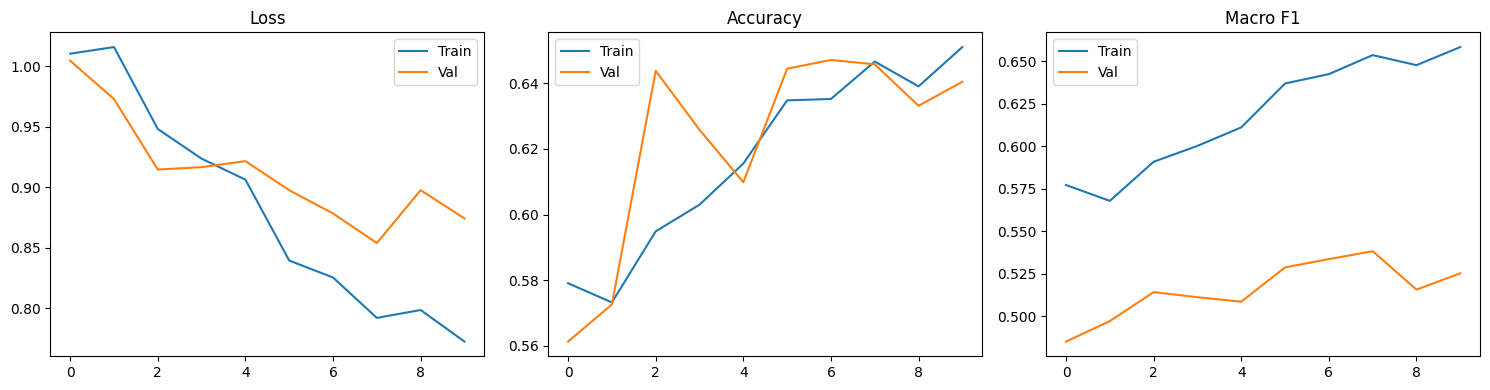


FINAL EVALUATION


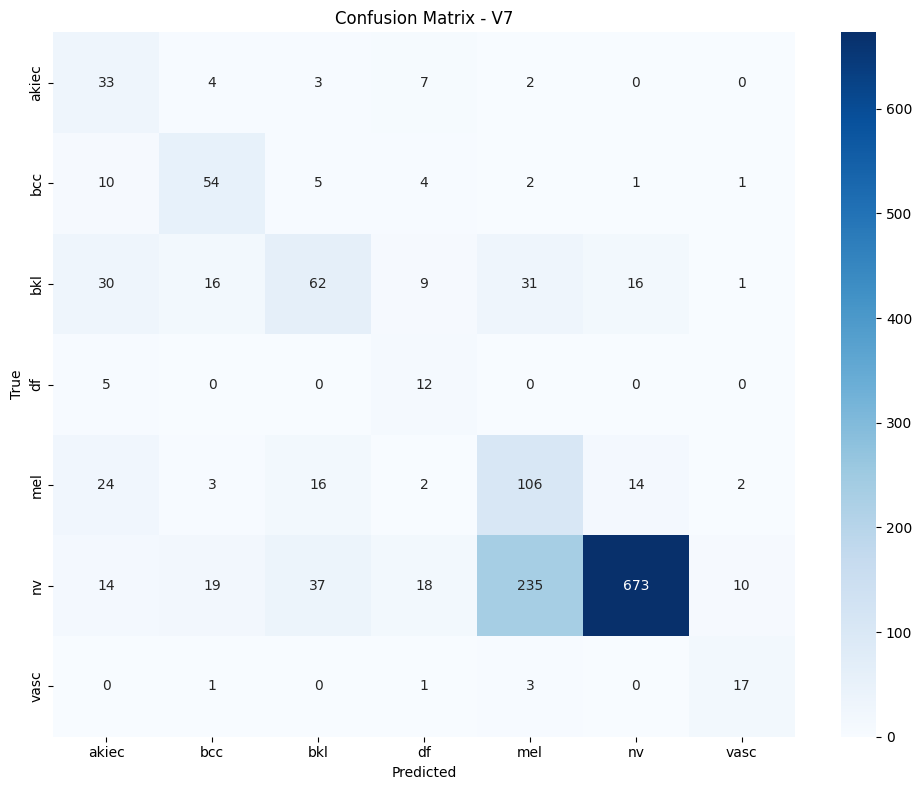


V7 TEST RESULTS - Spatial Morphology + Metadata Fusion
Accuracy: 0.6367
Macro F1: 0.5159
Weighted F1: 0.6754
Macro AUC: 0.9205

Per-class metrics:
  akiec : Precision=0.2845, Recall=0.6735, F1=0.4000
  bcc   : Precision=0.5567, Recall=0.7013, F1=0.6207
  bkl   : Precision=0.5041, Recall=0.3758, F1=0.4306
  df    : Precision=0.2264, Recall=0.7059, F1=0.3429
  mel   : Precision=0.2797, Recall=0.6347, F1=0.3883
  nv    : Precision=0.9560, Recall=0.6690, F1=0.7871
  vasc  : Precision=0.5484, Recall=0.7727, F1=0.6415

Target (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733
NEEDS IMPROVEMENT

Generating attention visualizations...
Saved attention visualizations to D:\amlan project\Kimi phase 4\output\checkpoints_phase4\attention_visualization.png

Results saved to: D:\amlan project\Kimi phase 4\output\checkpoints_phase4


In [29]:
# Plot + Final Test Evaluation
trainer.plot_history()
results = run_final_evaluation(model, test_loader, config, config.SAVE_DIR)